#Code

In [3]:
# ================================
# INSTALL LIBRARIES
# ================================
!pip install -q roboflow keras-cv

# ================================
# IMPORTS
# ================================
import tensorflow as tf
import keras
import keras_cv
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 59.3 MB/s eta 0:00:00


In [4]:
# ================================
# DOWNLOAD DATASET FROM ROBOFLOW
# ================================
from roboflow import Roboflow

rf = Roboflow(api_key="zjpSZV4zMOJbGmcR4EPT")
project = rf.workspace("science-research").project("science-research:-bone-classification-detection")
version = project.version(2)

dataset = version.download("voc")

print("Dataset path:", dataset.location)
print("Folders:", os.listdir(dataset.location))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Science-Research:-Bone-Classification-Detection-2 in voc:: 100%|██████████| 921/921 [00:00<00:00, 4495.69it/s]

Dataset path: /content/Science-Research:-Bone-Classification-Detection-2
Folders: ['valid', 'test', 'README.roboflow.txt', 'README.dataset.txt', 'train']


In [5]:
# ================================
# DEFINE CLASSES
# ================================
CLASSES = [
    "carpal",
    "metacarpal",
    "phalanges",
    "radius",
    "ulna"
]

CLASS_MAPPING = {name: idx for idx, name in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

BATCH_SIZE = 4

print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 5


In [6]:
# ================================
# PARSE VOC ANNOTATION
# ================================
def parse_voc_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    boxes = []
    classes = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip().lower()

        if class_name not in CLASS_MAPPING:
            continue

        classes.append(CLASS_MAPPING[class_name])

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        boxes.append([xmin, ymin, xmax, ymax])

    return boxes, classes

In [7]:
# ================================
# LOAD DATA FUNCTION
# ================================
import os
def load_data(folder_path):
    image_paths = []
    all_boxes = []
    all_classes = []

    for file in os.listdir(folder_path):

        if not file.endswith(".jpg"):
            continue

        img_path = os.path.join(folder_path, file)
        xml_path = img_path.replace(".jpg", ".xml")

        if not os.path.exists(xml_path):
            continue

        boxes, classes = parse_voc_annotation(xml_path)

        if len(boxes) > 0:
            image_paths.append(img_path)
            all_boxes.append(boxes)
            all_classes.append(classes)

    return image_paths, all_boxes, all_classes


# ================================
# LOAD TRAIN / VALID / TEST
# ================================
train_dir = os.path.join(dataset.location, "train")
valid_dir = os.path.join(dataset.location, "valid")
test_dir  = os.path.join(dataset.location, "test")

train_img, train_boxes, train_cls = load_data(train_dir)
valid_img, valid_boxes, valid_cls = load_data(valid_dir)

print("Train:", len(train_img))
print("Valid:", len(valid_img))

Train: 403
Valid: 39


In [8]:
# ================================
# CREATE DATASET
# ================================
def create_dataset(image_paths, boxes, classes):

    box_tensor = tf.ragged.constant(boxes, dtype=tf.float32)
    class_tensor = tf.ragged.constant(classes, dtype=tf.float32)
    path_tensor = tf.constant(image_paths)

    dataset = tf.data.Dataset.from_tensor_slices(
        (path_tensor, class_tensor, box_tensor)
    )

    def load_image(path, cls, box):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(img, tf.float32)

        return {
            "images": img,
            "bounding_boxes": {
                "classes": cls,
                "boxes": box
            }
        }

    return dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)


train_ds = create_dataset(train_img, train_boxes, train_cls)
valid_ds = create_dataset(valid_img, valid_boxes, valid_cls)

In [14]:
# ================================
# RESIZE LAYER
# ================================
resizing_layer = keras_cv.layers.Resizing(
    640, 640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xyxy"
)

# ================================
# DATA AUGMENTATION (VERY IMPORTANT)
# ================================
# ================================
# DATA AUGMENTATION (FINAL FIXED)
# ================================
augmenter = keras_cv.layers.Augmenter(
    layers=[
        keras_cv.layers.RandomFlip(
            mode="horizontal",
            bounding_box_format="xyxy"
        ),

        keras_cv.layers.JitteredResize(
            target_size=(640, 640),
            scale_factor=(0.8, 1.2),
            bounding_box_format="xyxy"
        )
    ]
)

        # These layers DO NOT take bounding_box_format

keras_cv.layers.RandomZoom(
            height_factor=0.2,
            width_factor=0.2
        ),

keras_cv.layers.RandomTranslation(
            height_factor=0.1,
            width_factor=0.1
        ),

        # This handles bbox properly
keras_cv.layers.JitteredResize(
            target_size=(640, 640),
            scale_factor=(0.8, 1.2),
            bounding_box_format="xyxy"

)

# ================================
# PREPARE DATASET
# ================================
def prepare_dataset(dataset, batch_size, is_training=True):

    dataset = dataset.ragged_batch(batch_size)

    if is_training:
        # Augmenter already resizes → DO NOT resize again
        dataset = dataset.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        # Only resize validation
        dataset = dataset.map(resizing_layer, num_parallel_calls=tf.data.AUTOTUNE)

    def to_dense(x):
        boxes = x["bounding_boxes"]["boxes"].to_tensor(-1.0)
        classes = x["bounding_boxes"]["classes"].to_tensor(-1.0)

        return x["images"], {"boxes": boxes, "classes": classes}

    return dataset.map(to_dense).prefetch(tf.data.AUTOTUNE)
train_dataset = prepare_dataset(train_ds, BATCH_SIZE, True)
valid_dataset = prepare_dataset(valid_ds, BATCH_SIZE, False)

In [15]:
# ================================
# BUILD MODEL
# ================================
backbone = keras_cv.models.YOLOV8Backbone.from_preset("yolo_v8_s_backbone")

model = keras_cv.models.YOLOV8Detector(
    num_classes=NUM_CLASSES,
    bounding_box_format="xyxy",
    backbone=backbone,
    fpn_depth=2
)

# Build static graph (important for stability)
dummy = tf.zeros((1, 640, 640, 3))
_ = model(dummy)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4   # LOWER = more stable learning
    ),
    classification_loss="binary_crossentropy",
    box_loss="ciou"
)
model.summary()

100%|██████████| 632/632 [00:00<00:00, 1.68MB/s]


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │  5,089,760 │ input_layer_1[0]… │
│ (Functional)        │ None, 128),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 512)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 768)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │    196,608 │ concatenate_5[0]… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │      1,024 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 128),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    147,456 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        512 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    147,456 │ pa_fpn_p4p5_pre_

 Total params: 13,210,159 (50.39 MB)

 Trainable params: 13,187,823 (50.31 MB)

 Non-trainable params: 22,336 (87.25 KB)

In [16]:
# ================================
# TRAIN MODEL
# ================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best.keras",
        save_best_only=True
    ),

    # Stop only when REALLY no improvement
    keras.callbacks.EarlyStopping(
        patience=20,
        restore_best_weights=True
    ),

    # Reduce LR automatically when stuck
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=5,
        verbose=1
    )
]
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - box_loss: 2.7538 - class_loss: 51.1090 - loss: 53.8689 - val_box_loss: 3.1300 - val_class_loss: 32.6785 - val_loss: 35.8835 - learning_rate: 1.0000e-04
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - box_loss: 2.4857 - class_loss: 35.3374 - loss: 37.8121 - val_box_loss: 2.9123 - val_class_loss: 29.3783 - val_loss: 32.3683 - learning_rate: 1.0000e-04
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 242ms/step - box_loss: 2.3472 - class_loss: 28.4756 - loss: 30.8205 - val_box_loss: 2.7775 - val_class_loss: 24.8245 - val_loss: 27.6874 - learning_rate: 1.0000e-04
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 25s 243ms/step - box_loss: 2.2752 - class_loss: 23.1882 - loss: 25.4525 - val_box_loss: 2.7155 - val_class_loss: 19.3095 - val_loss: 22.0721 - learning_rate: 1.0000e-04
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 236ms/step - box_loss: 2.1713 - class_loss: 18.4858 - loss: 20.6545 - val_box_loss: 2.5513 - val_class_loss: 15.9177 - val

In [17]:
# ================================
# LOAD TRAINED MODEL
# ================================
model = keras.models.load_model("best.keras", compile=False)

In [18]:
# ================================
# APPLY NON-MAX SUPPRESSION
# ================================
model.prediction_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
    bounding_box_format="xyxy",
    from_logits=False,
    iou_threshold=0.5,        # remove overlapping boxes
    confidence_threshold=0.3, # ignore weak detections
    max_detections=100
)

In [19]:
# ================================
# LOAD TEST IMAGE
# ================================
test_image_path = test_dir + "/" + os.listdir(test_dir)[0]

img = cv2.imread(test_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

original = img.copy()

# Resize to model input
img_resized = cv2.resize(img, (640, 640))
img_tensor = tf.expand_dims(img_resized, axis=0)
img_tensor = tf.cast(img_tensor, tf.float32)

In [21]:
# ================================
# RUN INFERENCE
# ================================
# ================================
# FIX FOR NMS ERROR
# ================================
tf.config.optimizer.set_jit(False)       # Disable XLA
tf.config.run_functions_eagerly(True)    # Force eager mode
pred = model.predict(img_tensor, verbose=0)

boxes = pred["boxes"][0]
classes = pred["classes"][0]
scores = pred["confidence"][0]

Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.


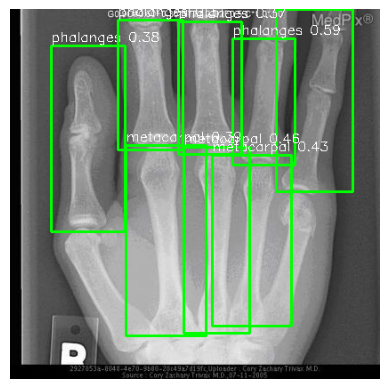

In [22]:
# ================================
# DRAW PREDICTIONS
# ================================
h, w = original.shape[:2]

scale_x = w / 640
scale_y = h / 640

for i in range(len(boxes)):
    if classes[i] == -1 or scores[i] < 0.3:
        continue

    xmin, ymin, xmax, ymax = boxes[i]

    xmin = int(xmin * scale_x)
    ymin = int(ymin * scale_y)
    xmax = int(xmax * scale_x)
    ymax = int(ymax * scale_y)

    label = CLASSES[int(classes[i])]
    conf = scores[i]

    cv2.rectangle(original, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(original, f"{label} {conf:.2f}",
                (xmin, ymin - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255, 255, 255), 1)

import matplotlib.pyplot as plt
plt.imshow(original)
plt.axis("off")
plt.show()